# IMDB Dataset of 50K Movie Reviews
**About Dataset**

IMDB dataset having 50K movie reviews for natural language processing or Text analytics.
This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training and 25,000 for testing. So, predict the number of positive and negative reviews using either classification or deep learning algorithms.

In [155]:
import kagglehub

path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [156]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import re
import os
import nltk

import torch
import torch.nn as nn
import torch.nn.functional as F

from nltk.corpus import stopwords
from collections import Counter
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [157]:
print(os.listdir(path))

['IMDB Dataset.csv']


In [158]:
df = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"))

In [159]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [160]:
df['sentiment'] = df['sentiment'].replace({'positive': 1, 'negative': 0})
df['review'] = df['review'].str.lower()

/tmp/ipykernel_1047/377254251.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace({'positive': 1, 'negative': 0})


In [161]:
df.head(10)

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production. <br /><br />the...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there's a family where a little boy ...,0
4,"petter mattei's ""love in the time of money"" is...",1
5,"probably my all-time favorite movie, a story o...",1
6,i sure would like to see a resurrection of a u...,1
7,"this show was an amazing, fresh & innovative i...",0
8,encouraged by the positive comments about this...,0
9,if you like original gut wrenching laughter yo...,1


In [162]:
df['review'][42]

'of all the films i have seen, this one, the rage, has got to be one of the worst yet. the direction, logic, continuity, changes in plot-script and dialog made me cry out in pain. "how could anyone come up with something so crappy"? gary busey is know for his "b" movies, but this is a sure "w" movie. (w=waste).<br /><br />take for example: about two dozen fbi & local law officers surround a trailer house with a jeep wagoneer. inside the jeep is ma and is "confused" as to why all the cops are about. within seconds a huge gun battle ensues, ma being killed straight off. the cops blast away at the jeep with gary and company blasting away at them. the cops fall like dominoes and the jeep with gary drives around in circles and are not hit by one single bullet/pellet. ma is killed and gary seems to not to have noticed-damn that guy is tough. truly a miracle, not since the six-shooter held 300 bullets has there been such a miracle.'

Для обработки датасета нужно удалить HTML-разметку и ссылки, так как для последующей обработки это источник шума, ведь нам нужны "чистые" данные, а разметка и ссылки это лишь метаданные, которые искажают результат.

In [163]:
def remove_html(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'', text)

def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

def remove_punc(text):
    return text.translate(str.maketrans('', '', string.punctuation))

In [164]:
df['review'] = df['review'].apply(remove_html)
df['review'] = df['review'].apply(remove_url)

In [165]:
is_cuda = torch.cuda.is_available()

if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")

GPU is available


In [166]:
X, y = df['review'].values, df['sentiment'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=72)

print(f'Shape of train data is {X_train.shape}')
print(f'Shape of test data is {X_test.shape}')

Shape of train data is (37500,)
Shape of test data is (12500,)


In [167]:
def preprocess_string(s):
    s = re.sub(r"[^\w\s]", '', s) # Убираем все кроме букв
    s = re.sub(r"\s+", '', s) # Убираем лишние пробелы
    s = re.sub(r"\d", '', s) # Убираем цифры
    return s

In [168]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [169]:
def tockenize(x_train, y_train, x_val, y_val):
    word_list = []

    stop_words = set(stopwords.words('english'))
    for sent in x_train:
        for word in sent.lower().split():
            word = preprocess_string(word)
            if word not in stop_words and word != '':
                word_list.append(word)

    corpus = Counter(word_list)
    corpus_ = sorted(corpus, key=corpus.get, reverse=True)[:1024]
    onehot_dict = {w: i + 1 for i, w in enumerate(corpus_)}

    final_list_train, final_list_test = [], []
    for sent in x_train:
        final_list_train.append([onehot_dict[preprocess_string(word)]
                                  for word in sent.lower().split()
                                  if preprocess_string(word) in onehot_dict])
    for sent in x_val:
        final_list_test.append([onehot_dict[preprocess_string(word)]
                                 for word in sent.lower().split()
                                 if preprocess_string(word) in onehot_dict])

    encoded_train = list(y_train)
    encoded_test = list(y_val)

    return (np.array(final_list_train, dtype=object), np.array(encoded_train),
            np.array(final_list_test, dtype=object), np.array(encoded_test),
            onehot_dict)

In [170]:
X_train, y_train, X_test, y_test, voc = tockenize(X_train, y_train, X_test, y_test)

In [171]:
voc

{'movie': 1,
 'film': 2,
 'one': 3,
 'like': 4,
 'good': 5,
 'even': 6,
 'would': 7,
 'time': 8,
 'really': 9,
 'see': 10,
 'story': 11,
 'much': 12,
 'well': 13,
 'get': 14,
 'bad': 15,
 'great': 16,
 'also': 17,
 'people': 18,
 'dont': 19,
 'first': 20,
 'films': 21,
 'movies': 22,
 'made': 23,
 'make': 24,
 'way': 25,
 'could': 26,
 'characters': 27,
 'think': 28,
 'watch': 29,
 'many': 30,
 'seen': 31,
 'two': 32,
 'character': 33,
 'never': 34,
 'love': 35,
 'acting': 36,
 'plot': 37,
 'little': 38,
 'know': 39,
 'best': 40,
 'show': 41,
 'life': 42,
 'ever': 43,
 'better': 44,
 'scene': 45,
 'still': 46,
 'say': 47,
 'end': 48,
 'man': 49,
 'scenes': 50,
 'something': 51,
 'go': 52,
 'back': 53,
 'im': 54,
 'real': 55,
 'watching': 56,
 'thing': 57,
 'doesnt': 58,
 'didnt': 59,
 'actors': 60,
 'years': 61,
 'though': 62,
 'actually': 63,
 'funny': 64,
 'makes': 65,
 'find': 66,
 'another': 67,
 'nothing': 68,
 'going': 69,
 'work': 70,
 'look': 71,
 'lot': 72,
 'new': 73,
 'every

Для дальнейшей обработки необходим паддинг, добавим отсупы к каждой последовательстности до максимальной длины.

In [172]:
review_len = [len(i) for i in X_train]
pd.Series(review_len).describe()

,0
count,37500.000000
mean,66.885467
std,46.138082
min,0.000000
25%,38.000000
50%,53.000000
75%,81.000000
max,600.000000


In [173]:
def padding(sentences, seq_len=512):
    features = np.zeros((len(sentences), seq_len), dtype=int)

    for index, review in enumerate(sentences):
        if len(review) != 0:
            features[index, -len(review):] = np.array(review)[:seq_len]

    return features

In [174]:
X_train_pad = padding(X_train)
X_test_pad = padding(X_test)

In [175]:
train_data = TensorDataset(torch.from_numpy(X_train_pad), torch.from_numpy(y_train))
valid_data = TensorDataset(torch.from_numpy(X_test_pad), torch.from_numpy(y_test))

batch_size = 64

train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size, drop_last=True)
valid_loader = DataLoader(valid_data, shuffle=False, batch_size=batch_size, drop_last=True)

In [176]:
dataiter = iter(train_loader)
sample_x, sample_y = next(dataiter)

print('Sample input size: ', sample_x.size())

Sample input size:  torch.Size([64, 512])


In [177]:
class SentimentRNN(nn.Module):
    def __init__(self, no_layers, voc_size, hidden_dim, embedding_dim, drop_prob=0.5):
        super(SentimentRNN,self).__init__()

        self.output_dim = output_dim
        self.hidden_dim = hidden_dim

        self.no_layers = no_layers
        self.voc_size = voc_size

        self.embedding = nn.Embedding(voc_size, embedding_dim)

        self.lstm = nn.LSTM(input_size=embedding_dim,hidden_size=self.hidden_dim,
                           num_layers=no_layers, batch_first=True)


        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(self.hidden_dim, output_dim)
        self.activation = nn.Sigmoid()

    def forward(self,x,hidden):
        batch_size = x.size(0)

        embeds = self.embedding(x)

        lstm_out, hidden = self.lstm(embeds, hidden)

        lstm_out = lstm_out.contiguous().view(-1, self.hidden_dim)

        out = self.dropout(lstm_out)
        out = self.fc(out)

        sig_out = self.activation(out)

        sig_out = sig_out.view(batch_size, -1)

        sig_out = sig_out[:, -1]
        return sig_out, hidden



    def init_hidden(self, batch_size):
        h0 = torch.zeros((self.no_layers,batch_size,self.hidden_dim)).to(device)
        c0 = torch.zeros((self.no_layers,batch_size,self.hidden_dim)).to(device)
        hidden = (h0, c0)
        return hidden

In [178]:
no_layers = 2
voc_size = len(voc) + 1
embedding_dim = 64
output_dim = 1
hidden_dim = 256


model = SentimentRNN(no_layers, voc_size, hidden_dim, embedding_dim, drop_prob=0.42)

model.to(device)

SentimentRNN(
  (embedding): Embedding(1025, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (activation): Sigmoid()
)

In [179]:
print(model)

SentimentRNN(
  (embedding): Embedding(1025, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (activation): Sigmoid()
)


In [180]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

def accuracy_(pred, label):
    pred = torch.round(pred.squeeze())
    return torch.sum(pred == label.squeeze()).item()

In [181]:
def run_epoch(model, loader, criterion, optimizer, device, is_train=True):
    model.train() if is_train else model.eval()

    total_loss, total_acc = 0.0, 0.0
    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            h = model.init_hidden(inputs.size(0))
            h = tuple(t.data for t in h)

            output, h = model(inputs, h)
            loss = criterion(output.squeeze(), labels.float())

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), clip)
                optimizer.step()

            total_loss += loss.item()
            total_acc  += accuracy_(output, labels)

    avg_loss = total_loss / len(loader)
    avg_acc  = total_acc  / len(loader.dataset)
    return avg_loss, avg_acc


def train(model, train_loader, valid_loader, criterion, optimizer, device, epochs=6):
    best_val_loss = float('inf')
    history = {"tr_loss": [], "vl_loss": [], "tr_acc": [], "vl_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, is_train=True)
        vl_loss, vl_acc = run_epoch(model, valid_loader, criterion, optimizer, device, is_train=False)

        history["tr_loss"].append(tr_loss)
        history["vl_loss"].append(vl_loss)
        history["tr_acc"].append(tr_acc)
        history["vl_acc"].append(vl_acc)

        print(f"Epoch {epoch}/{epochs}")
        print(f"  train loss: {tr_loss:.4f}  acc: {tr_acc*100:.2f}%")
        print(f"  valid loss: {vl_loss:.4f}  acc: {vl_acc*100:.2f}%")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "state_dict.pt")
            print(f"Val loss improved, model saved")

        print("-" * 50)

    return history


history = train(model, train_loader, valid_loader, criterion, optimizer, device, epochs=5)

Epoch 1/5
  train loss: 0.5300  acc: 73.21%
  valid loss: 0.4516  acc: 78.82%
Val loss improved, model saved
--------------------------------------------------
Epoch 2/5
  train loss: 0.3977  acc: 82.76%
  valid loss: 0.4567  acc: 79.86%
--------------------------------------------------
Epoch 3/5
  train loss: 0.3535  acc: 84.94%
  valid loss: 0.3343  acc: 85.70%
Val loss improved, model saved
--------------------------------------------------
Epoch 4/5
  train loss: 0.3158  acc: 86.54%
  valid loss: 0.3572  acc: 84.60%
--------------------------------------------------
Epoch 5/5
  train loss: 0.2953  acc: 87.57%
  valid loss: 0.3176  acc: 86.46%
Val loss improved, model saved
--------------------------------------------------


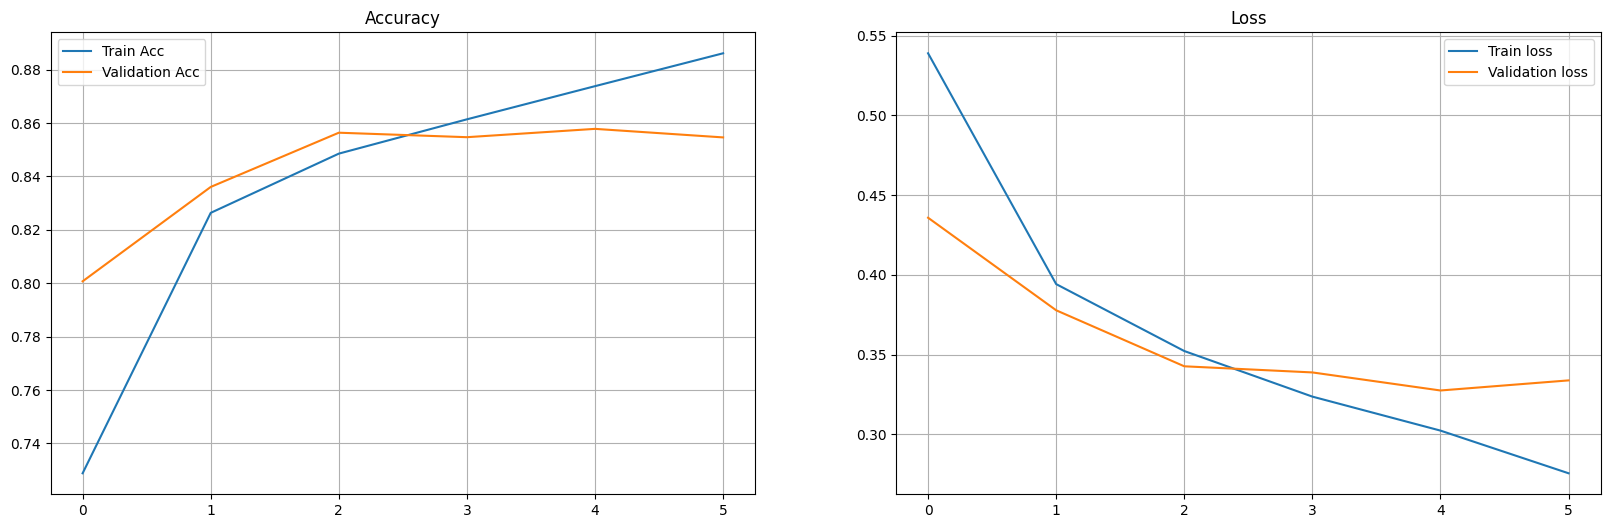

In [183]:
fig = plt.figure(figsize = (20, 6))
plt.subplot(1, 2, 1)
plt.plot(epoch_tr_acc, label='Train Acc')
plt.plot(epoch_vl_acc, label='Validation Acc')
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epoch_tr_loss, label='Train loss')
plt.plot(epoch_vl_loss, label='Validation loss')
plt.title("Loss")
plt.legend()
plt.grid()

plt.show()

In [190]:
def predict_sentiment(text: str) -> dict:
    """
    Предсказывает тональность текста.
    Возвращает словарь с меткой и скором
    """
    tokens = [
        voc[preprocess_string(word)]
        for word in text.split()
        if preprocess_string(word) in voc
    ]

    if not tokens:
        raise ValueError("Текст не содержит известных слов из словаря")

    sequence = np.expand_dims(np.array(tokens), axis=0)
    inputs = torch.from_numpy(padding(sequence, 512)).to(device)

    model.eval()
    with torch.no_grad():
        h = tuple(t.data for t in model.init_hidden(batch_size=1))
        score, _ = model(inputs, h)

    score = score.item()
    label = "positive" if score > 0.5 else "negative"
    confidence = score if label == "positive" else 1 - score

    return {"label": label, "confidence": confidence, "score": score}

In [193]:
def print_prediction(df, index: int):
    """Выводит реальную и предсказанную тональность для записи из датафрейма."""
    text = df["review"][index]
    actual = df["sentiment"][index]
    result = predict_sentiment(text)

    print(f"Review:\n{text}")
    print("=" * 70)
    print(f"Actual    : {'positive' if actual == 1 else 'negative'}")
    print(f"Predicted : {result['label']}  (уверенность: {result['confidence']:.1%})")


In [196]:
print_prediction(df, index=42)

Review:
of all the films i have seen, this one, the rage, has got to be one of the worst yet. the direction, logic, continuity, changes in plot-script and dialog made me cry out in pain. "how could anyone come up with something so crappy"? gary busey is know for his "b" movies, but this is a sure "w" movie. (w=waste).take for example: about two dozen fbi & local law officers surround a trailer house with a jeep wagoneer. inside the jeep is ma and is "confused" as to why all the cops are about. within seconds a huge gun battle ensues, ma being killed straight off. the cops blast away at the jeep with gary and company blasting away at them. the cops fall like dominoes and the jeep with gary drives around in circles and are not hit by one single bullet/pellet. ma is killed and gary seems to not to have noticed-damn that guy is tough. truly a miracle, not since the six-shooter held 300 bullets has there been such a miracle.
Actual    : negative
Predicted : negative  (уверенность: 96.1%)


Окончательно имеем модель с accuracy=85.7% на тесте.

В дальнейшем можно улучшить модель, использовав предобученные эмбединнги слов (GloVe), попробовать двунаправленный LSTM, либо вовсе другую модель.